In [13]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.model import ECG_CNN1D

dispositivo = torch.device('cpu')  # Grad-CAM sobre un solo ejemplo no necesita GPU

CLASES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

In [14]:
modelo = ECG_CNN1D(num_leads=12, num_classes=5).to(dispositivo)
modelo.load_state_dict(torch.load('../models/mejor_modelo.pt', map_location=dispositivo, weights_only=True))
modelo.eval()

# Queremos "espiar" justo después de la última capa ReLU del bloque3,
# antes de que el AdaptiveAvgPool1d comprima toda la información temporal.
# Recuerda la arquitectura: bloque3 = [Conv1d, BatchNorm1d, ReLU, AdaptiveAvgPool1d]
capa_objetivo = modelo.bloque3[2]

from src.gradcam import GradCAM1D
gradcam = GradCAM1D(modelo, capa_objetivo)

In [15]:
from torch.utils.data import DataLoader
from src.dataset import ECGDataset
from src.train import evaluar
from src.losses import FocalLossMultiLabel

X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

test_dataset = ECGDataset('../data/processed/X_test.npy', '../data/processed/y_test.npy')
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

_, predicciones_test, etiquetas_test = evaluar(modelo, test_loader, FocalLossMultiLabel(), dispositivo)

In [16]:
indice_clase = CLASES.index('HYP')

positivos_reales = np.where(etiquetas_test[:, indice_clase] == 1)[0]
probas_de_esos_casos = predicciones_test[positivos_reales, indice_clase]
idx_ejemplo = positivos_reales[np.argmax(probas_de_esos_casos)]

print(f"Índice del ejemplo elegido: {idx_ejemplo}")
print(f"Probabilidad predicha para HYP: {predicciones_test[idx_ejemplo, indice_clase]:.4f}")

Índice del ejemplo elegido: 1087
Probabilidad predicha para HYP: 0.6913


In [17]:
def graficar_gradcam(señal, cam, derivacion=1, nombre_clase='', probabilidad=None, ruta_guardado=None):
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.imshow(
        cam[np.newaxis, :], cmap='Reds', aspect='auto', alpha=0.5,
        extent=[0, len(cam), señal[:, derivacion].min(), señal[:, derivacion].max()]
    )
    ax.plot(señal[:, derivacion], color='black', linewidth=1.3)

    titulo = f'Grad-CAM — clase {nombre_clase}'
    if probabilidad is not None:
        titulo += f' (probabilidad predicha: {probabilidad:.2f})'
    ax.set_title(titulo)
    ax.set_xlabel('Muestras (tiempo)')
    ax.set_ylabel('Amplitud normalizada')

    if ruta_guardado:
        fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
    plt.show()

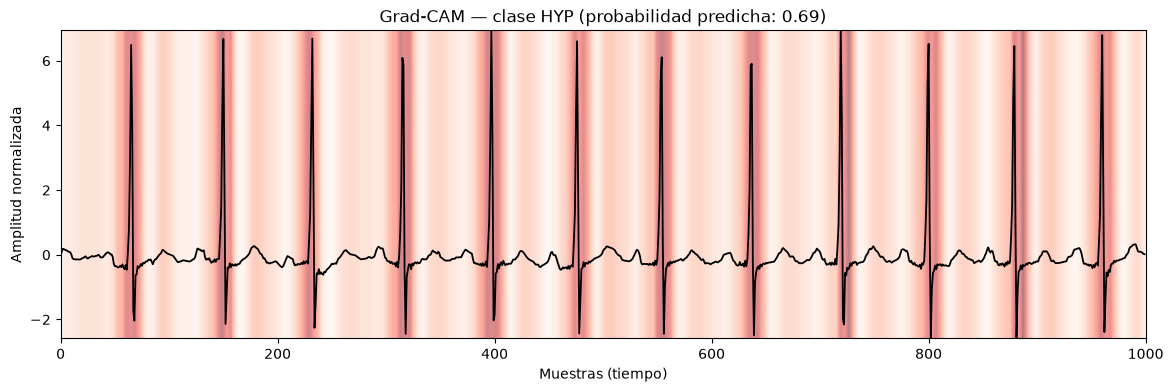

In [18]:
import os
os.makedirs('../assets', exist_ok=True)

señal_ejemplo = X_test[idx_ejemplo]  # forma (1000, 12), ya preprocesada
señal_tensor = torch.tensor(señal_ejemplo, dtype=torch.float32).transpose(0, 1)  # (12, 1000)

cam, probabilidad = gradcam.generar(señal_tensor, indice_clase)

graficar_gradcam(
    señal_ejemplo, cam,
    derivacion=1, nombre_clase='HYP', probabilidad=probabilidad,
    ruta_guardado='../assets/gradcam_hyp_ejemplo.png'
)

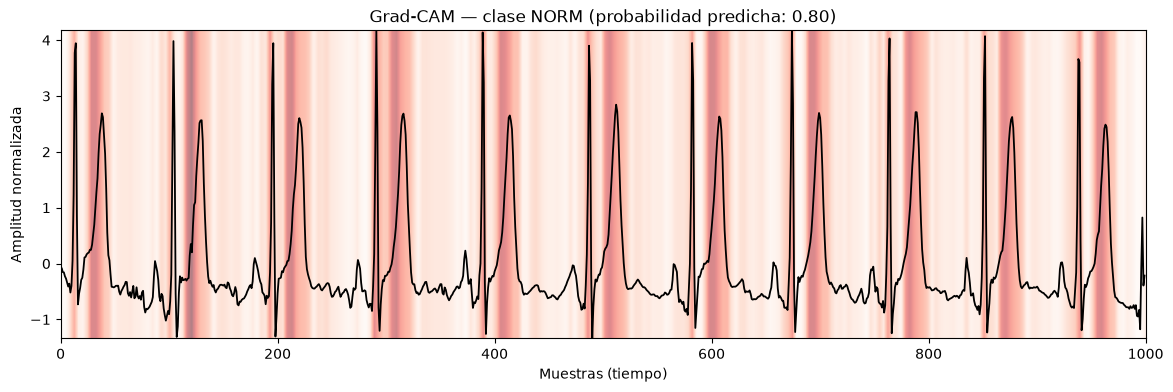

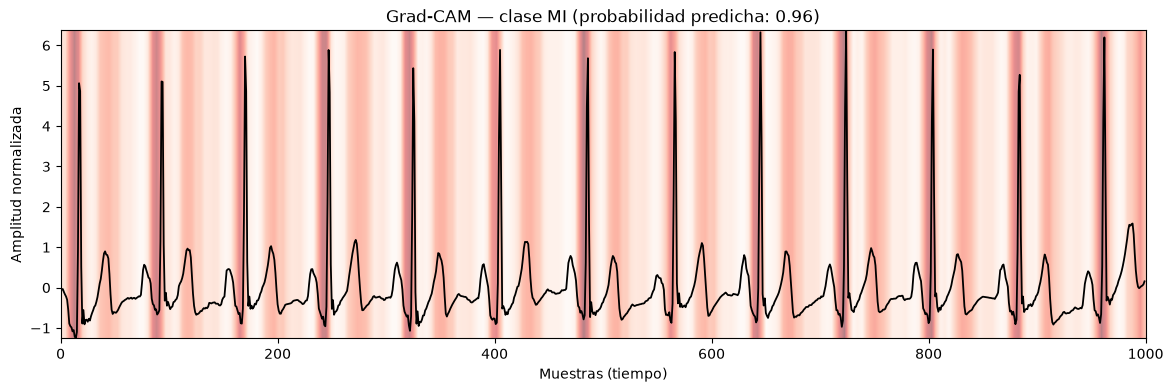

In [19]:
for nombre_clase in ['NORM', 'MI']:
    indice_clase = CLASES.index(nombre_clase)
    positivos_reales = np.where(etiquetas_test[:, indice_clase] == 1)[0]
    probas_de_esos_casos = predicciones_test[positivos_reales, indice_clase]
    idx_ejemplo = positivos_reales[np.argmax(probas_de_esos_casos)]

    señal_ejemplo = X_test[idx_ejemplo]
    señal_tensor = torch.tensor(señal_ejemplo, dtype=torch.float32).transpose(0, 1)
    cam, probabilidad = gradcam.generar(señal_tensor, indice_clase)

    graficar_gradcam(
        señal_ejemplo, cam,
        derivacion=1, nombre_clase=nombre_clase, probabilidad=probabilidad,
        ruta_guardado=f'../assets/gradcam_{nombre_clase.lower()}_ejemplo.png'
    )

In [20]:
from src.data_utils import cargar_metadatos_limpios

df = cargar_metadatos_limpios()

In [21]:
import requests
import wfdb

# Cogemos un ECG crudo real (sin preprocesar) del dataset
ecg_id_prueba = df.index[10]  # requiere haber cargado 'df' con cargar_metadatos_limpios()
ruta = '../data/' + df.loc[ecg_id_prueba, 'filename_lr']
record = wfdb.rdrecord(ruta)
señal_cruda = record.p_signal

respuesta = requests.post(
    "http://127.0.0.1:8000/predecir",
    json={"señal": señal_cruda.tolist()}
)
print(respuesta.json())

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /predecir (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No se puede establecer una conexión ya que el equipo de destino denegó expresamente dicha conexión"))

In [ ]:
import json
print(json.dumps({"señal": señal_cruda.tolist()}))

{"se\u00f1al": [[0.199, 0.084, -0.115, -0.142, 0.157, -0.015, -0.146, 0.038, 0.157, -0.038, 0.041, 0.127], [0.231, 0.085, -0.146, -0.158, 0.188, -0.031, -0.157, 0.065, 0.184, -0.009, 0.074, 0.159], [0.251, 0.089, -0.163, -0.17, 0.207, -0.037, -0.176, 0.092, 0.23, 0.039, 0.138, 0.216], [0.279, 0.087, -0.193, -0.183, 0.236, -0.053, -0.189, 0.089, 0.267, 0.082, 0.18, 0.262], [0.308, 0.121, -0.187, -0.214, 0.247, -0.032, -0.212, 0.077, 0.27, 0.102, 0.212, 0.287], [0.312, 0.143, -0.17, -0.227, 0.241, -0.013, -0.218, 0.064, 0.269, 0.092, 0.213, 0.294], [0.294, 0.114, -0.18, -0.204, 0.237, -0.033, -0.198, 0.037, 0.253, 0.09, 0.203, 0.291], [0.247, 0.068, -0.179, -0.157, 0.213, -0.056, -0.177, -0.01, 0.206, 0.07, 0.178, 0.247], [0.195, 0.019, -0.176, -0.106, 0.185, -0.078, -0.134, -0.065, 0.138, 0.001, 0.114, 0.176], [0.117, -0.05, -0.167, -0.034, 0.142, -0.108, -0.078, -0.12, 0.068, -0.067, 0.051, 0.113], [0.052, -0.107, -0.158, 0.028, 0.105, -0.132, -0.044, -0.171, 0.001, -0.122, -0.002, 0.0

COMPROBACIONES Y DEMÁS PARA MEJORAR LA PREDICCION DE HYP: 

In [23]:
import sys
sys.path.append('..')

import torch
import numpy as np
from torch.utils.data import DataLoader

from src.model import ECG_CNN1D
from src.dataset import ECGDataset
from src.losses import FocalLossMultiLabel
from src.train import evaluar

dispositivo = torch.device('cpu')
CLASES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Cargamos el modelo ya entrenado (el mismo que se usó para Grad-CAM)
modelo = ECG_CNN1D(num_leads=12, num_classes=5).to(dispositivo)
modelo.load_state_dict(torch.load('../models/mejor_modelo.pt', map_location=dispositivo, weights_only=True))
modelo.eval()

# Cargamos el conjunto de VALIDACIÓN (no el de test) — el umbral se elige aquí, no en test
val_dataset = ECGDataset('../data/processed/X_val.npy', '../data/processed/y_val.npy')
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

funcion_perdida = FocalLossMultiLabel(alpha=0.25, gamma=2.0)

# Obtenemos las predicciones en validación
_, predicciones_val, etiquetas_val = evaluar(modelo, val_loader, funcion_perdida, dispositivo)

indice_hyp = CLASES.index('HYP')

print("Predicciones de validación obtenidas, forma:", predicciones_val.shape)

Predicciones de validación obtenidas, forma: (2144, 5)


In [24]:
test_dataset = ECGDataset('../data/processed/X_test.npy', '../data/processed/y_test.npy')
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

_, predicciones_test, etiquetas_test = evaluar(modelo, test_loader, funcion_perdida, dispositivo)
print("Predicciones de test obtenidas, forma:", predicciones_test.shape)

Predicciones de test obtenidas, forma: (2156, 5)


In [25]:
print(f"{'Umbral':<10}{'Recall (detecta)':<20}{'Precisión (acierta)'}")
print("-" * 50)

for umbral_prueba in [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]:
    predicciones_binarias = (predicciones_val[:, indice_hyp] >= umbral_prueba).astype(int)

    verdaderos_positivos = ((predicciones_binarias == 1) & (etiquetas_val[:, indice_hyp] == 1)).sum()
    falsos_negativos = ((predicciones_binarias == 0) & (etiquetas_val[:, indice_hyp] == 1)).sum()
    falsos_positivos = ((predicciones_binarias == 1) & (etiquetas_val[:, indice_hyp] == 0)).sum()

    recall = verdaderos_positivos / (verdaderos_positivos + falsos_negativos + 1e-8)
    precision = verdaderos_positivos / (verdaderos_positivos + falsos_positivos + 1e-8)

    print(f"{umbral_prueba:<10}{recall:<20.3f}{precision:.3f}")

Umbral    Recall (detecta)    Precisión (acierta)
--------------------------------------------------
0.5       0.097               0.839
0.4       0.292               0.639
0.3       0.584               0.414
0.2       0.891               0.216
0.15      0.974               0.169
0.1       0.996               0.137


In [26]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, umbrales = roc_curve(etiquetas_val[:, indice_hyp], predicciones_val[:, indice_hyp])
estadistico_youden = tpr - fpr
mejor_indice = np.argmax(estadistico_youden)
mejor_umbral_hyp = umbrales[mejor_indice]

print(f"Umbral recomendado para HYP: {mejor_umbral_hyp:.3f}")
print(f"Con este umbral, en validación: sensibilidad = {tpr[mejor_indice]:.3f}, especificidad = {1 - fpr[mejor_indice]:.3f}")

Umbral recomendado para HYP: 0.263
Con este umbral, en validación: sensibilidad = 0.745, especificidad = 0.783


In [28]:
def calcular_recall_precision(predicciones_binarias, etiquetas_reales):
    vp = ((predicciones_binarias == 1) & (etiquetas_reales == 1)).sum()
    fn = ((predicciones_binarias == 0) & (etiquetas_reales == 1)).sum()
    fp = ((predicciones_binarias == 1) & (etiquetas_reales == 0)).sum()
    recall = vp / (vp + fn + 1e-8)
    precision = vp / (vp + fp + 1e-8)
    return recall, precision

predicciones_binarias_antiguas = (predicciones_test[:, indice_hyp] >= 0.5).astype(int)
predicciones_binarias_nuevas = (predicciones_test[:, indice_hyp] >= mejor_umbral_hyp).astype(int)

recall_antiguo, precision_antigua = calcular_recall_precision(predicciones_binarias_antiguas, etiquetas_test[:, indice_hyp])
recall_nuevo, precision_nueva = calcular_recall_precision(predicciones_binarias_nuevas, etiquetas_test[:, indice_hyp])

print(f"Umbral 0.5 (antiguo):  recall = {recall_antiguo:.3f}, precisión = {precision_antigua:.3f}")
print(f"Umbral {mejor_umbral_hyp:.3f} (optimizado): recall = {recall_nuevo:.3f}, precisión = {precision_nueva:.3f}")

Umbral 0.5 (antiguo):  recall = 0.134, precisión = 0.814
Umbral 0.263 (optimizado): recall = 0.721, precisión = 0.304


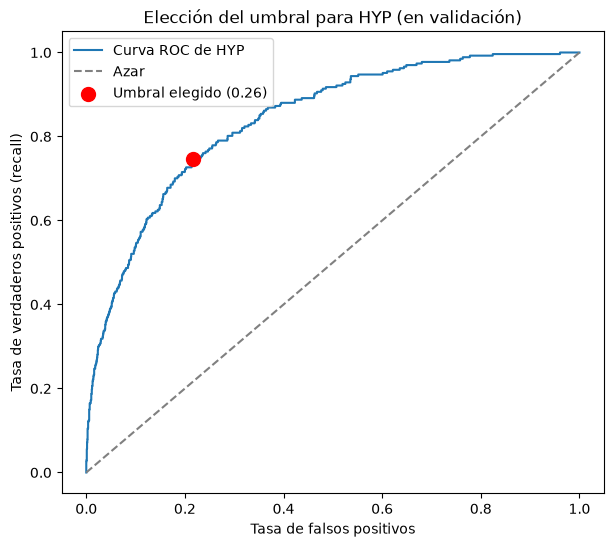

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label='Curva ROC de HYP')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
ax.scatter(fpr[mejor_indice], tpr[mejor_indice], color='red', s=100, zorder=5, label=f'Umbral elegido ({mejor_umbral_hyp:.2f})')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos (recall)')
ax.set_title('Elección del umbral para HYP (en validación)')
ax.legend()
fig.savefig('../assets/umbral_hyp.png', dpi=150, bbox_inches='tight')
plt.show()

ANALISIS DE SESGO DE EDAD y SEXO:

In [30]:
import sys
sys.path.append('..')

import numpy as np
from src.data_utils import cargar_metadatos_limpios
from src.preprocessing import procesar_ecg

df = cargar_metadatos_limpios()
df_test = df[df['split'] == 'test'].copy()

edades = []
sexos = []

for ecg_id, fila in df_test.iterrows():
    ruta_archivo = f"../data/{fila['filename_lr']}"
    señal = procesar_ecg(ruta_archivo)
    if señal is None:
        continue  # mismo criterio de descarte que en la Fase 2, para mantener el mismo orden

    edades.append(fila['age'])
    sexos.append(fila['sex'])

edades = np.array(edades)
sexos = np.array(sexos)

print(f"Metadatos recuperados: {len(edades)} registros")
print(f"Predicciones de test: {len(predicciones_test)} registros")
assert len(edades) == len(predicciones_test), "¡Descuadre! No sigas sin resolver esto primero."

Metadatos recuperados: 2156 registros
Predicciones de test: 2156 registros


In [32]:
from sklearn.metrics import roc_auc_score

CLASES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

print(f"{'Clase':<8}{'AUROC sexo 0':<15}{'AUROC sexo 1':<15}{'Diferencia'}")
print("-" * 55)

for i, clase in enumerate(CLASES):
    mascara_0 = sexos == 0
    mascara_1 = sexos == 1

    try:
        auroc_0 = roc_auc_score(etiquetas_test[mascara_0, i], predicciones_test[mascara_0, i])
    except ValueError:
        auroc_0 = None

    try:
        auroc_1 = roc_auc_score(etiquetas_test[mascara_1, i], predicciones_test[mascara_1, i])
    except ValueError:
        auroc_1 = None

    if auroc_0 is not None and auroc_1 is not None:
        diferencia = auroc_0 - auroc_1
        print(f"{clase:<8}{auroc_0:<15.4f}{auroc_1:<15.4f}{diferencia:+.4f}")
    else:
        print(f"{clase:<8}{'N/A (muestra insuficiente)'}")

# También el macro por sexo, para una visión de conjunto
auroc_macro_sexo0 = roc_auc_score(etiquetas_test[sexos == 0], predicciones_test[sexos == 0], average='macro')
auroc_macro_sexo1 = roc_auc_score(etiquetas_test[sexos == 1], predicciones_test[sexos == 1], average='macro')
print(f"\nAUROC macro sexo 0 (hombre): {auroc_macro_sexo0:.4f}")
print(f"AUROC macro sexo 1 (mujer):  {auroc_macro_sexo1:.4f}")

# Tamaños de muestra, para poder juzgar cuánto confiar en estos números
print(f"\nTamaño de muestra: sexo 0 = {(sexos==0).sum()}, sexo 1 = {(sexos==1).sum()}")

Clase   AUROC sexo 0   AUROC sexo 1   Diferencia
-------------------------------------------------------
NORM    0.9477         0.9326         +0.0151
MI      0.9365         0.9093         +0.0273
STTC    0.9507         0.9183         +0.0325
CD      0.9275         0.9043         +0.0231
HYP     0.8473         0.8329         +0.0144

AUROC macro sexo 0 (hombre): 0.9220
AUROC macro sexo 1 (mujer):  0.8995

Tamaño de muestra: sexo 0 = 1109, sexo 1 = 1047


In [33]:
es_90_o_mas = edades == 300
edades_validas = edades[~es_90_o_mas]

print(f"Registros con edad 90+ (código 300): {es_90_o_mas.sum()}")
print(f"Rango de edades normales: {edades_validas.min():.0f} - {edades_validas.max():.0f}")

grupos_edad = {
    '≤45 años': (edades <= 45) & (~es_90_o_mas),
    '46-60 años': (edades > 45) & (edades <= 60),
    '61-75 años': (edades > 60) & (edades <= 75),
    '76-89 años': (edades > 75) & (edades < 90),
    '90+ años (código 300)': es_90_o_mas,
}

print(f"{'Grupo':<25}{'N':<8}{'AUROC macro'}")
print("-" * 45)

for nombre_grupo, mascara in grupos_edad.items():
    n = mascara.sum()
    if n < 10:
        print(f"{nombre_grupo:<25}{n:<8}(muestra demasiado pequeña, se omite)")
        continue
    try:
        auroc = roc_auc_score(etiquetas_test[mascara], predicciones_test[mascara], average='macro')
        print(f"{nombre_grupo:<25}{n:<8}{auroc:.4f}")
    except ValueError:
        print(f"{nombre_grupo:<25}{n:<8}N/A")

Registros con edad 90+ (código 300): 32
Rango de edades normales: 4 - 89
Grupo                    N       AUROC macro
---------------------------------------------
≤45 años                 427     0.9123
46-60 años               536     0.9023
61-75 años               708     0.9004
76-89 años               453     0.8824
90+ años (código 300)    32      nan


c:\Users\Usuario\OneDrive - Universidad de Málaga\Escritorio\Marca personal\Ingenieria Biomec\ecg-structural-heart-disease\venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


c:\Users\Usuario\OneDrive - Universidad de Málaga\Escritorio\Marca personal\Ingenieria Biomec\ecg-structural-heart-disease\venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


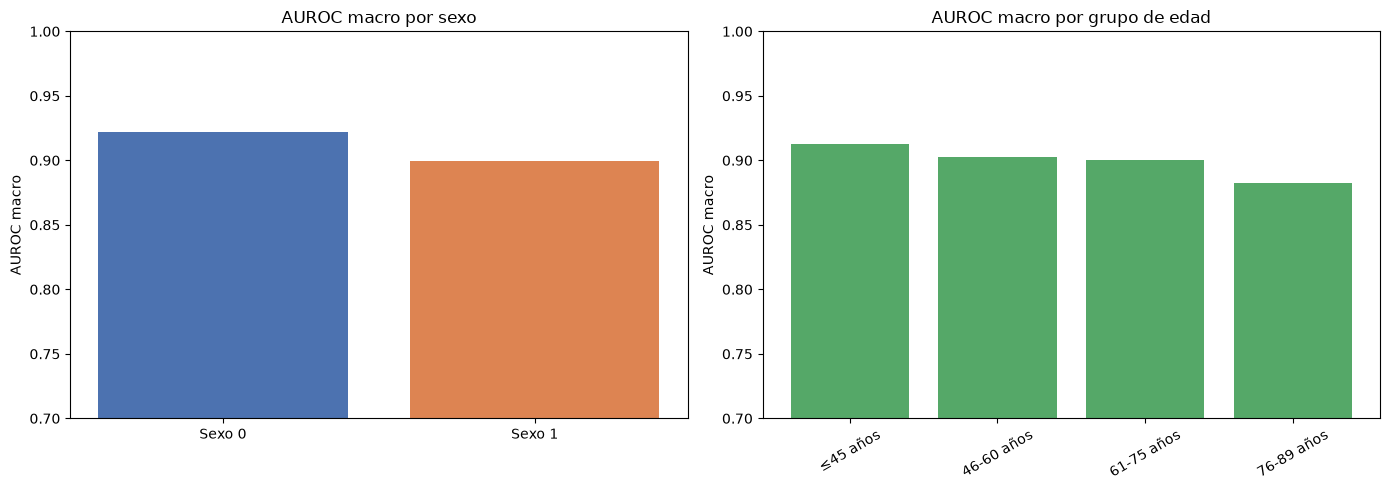

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de sexo
axes[0].bar(['Sexo 0', 'Sexo 1'], [auroc_macro_sexo0, auroc_macro_sexo1], color=['#4C72B0', '#DD8452'])
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title('AUROC macro por sexo')
axes[0].set_ylabel('AUROC macro')

# Gráfica de edad (solo grupos con muestra suficiente)
nombres_validos = []
valores_validos = []
for nombre_grupo, mascara in grupos_edad.items():
    if mascara.sum() >= 10:
        try:
            auroc = roc_auc_score(etiquetas_test[mascara], predicciones_test[mascara], average='macro')
            nombres_validos.append(nombre_grupo)
            valores_validos.append(auroc)
        except ValueError:
            pass

axes[1].bar(nombres_validos, valores_validos, color='#55A868')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_title('AUROC macro por grupo de edad')
axes[1].set_ylabel('AUROC macro')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
fig.savefig('../assets/sesgo_edad_sexo.png', dpi=150, bbox_inches='tight')
plt.show()